In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape
df.dtypes
df.isnull().sum() #yoxladim

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['shipping_days'] = (df['Ship Date'] - df['Order Date']).dt.days #gonderilme gunu
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [4]:
grouped = df.groupby(['Region', 'Category', 'Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum'}).reset_index()
grouped.head()

,Region,Category,Sub-Category,Sales,Profit
0,Central,Furniture,Bookcases,24157.1768,-1997.9043
1,Central,Furniture,Chairs,85230.6460,6592.7221
2,Central,Furniture,Furnishings,15254.3700,-3906.2168
3,Central,Furniture,Tables,39154.9710,-3559.6504
4,Central,Office Supplies,Appliances,23582.0330,-2638.6175


In [8]:
top5 = grouped.sort_values(by='Profit', ascending=False).head(5)
bottom5 = grouped.sort_values(by='Profit').head(5)
top5
bottom5

,Region,Category,Sub-Category,Sales,Profit
20,East,Furniture,Tables,39139.807,-11025.3801
37,South,Furniture,Tables,43916.192,-4623.0579
2,Central,Furniture,Furnishings,15254.370,-3906.2168
3,Central,Furniture,Tables,39154.971,-3559.6504
4,Central,Office Supplies,Appliances,23582.033,-2638.6175


In [9]:
grouped[grouped['Profit'] < 0] #menfi menfeet ucun

,Region,Category,Sub-Category,Sales,Profit
0,Central,Furniture,Bookcases,24157.1768,-1997.9043
2,Central,Furniture,Furnishings,15254.3700,-3906.2168
3,Central,Furniture,Tables,39154.9710,-3559.6504
4,Central,Office Supplies,Appliances,23582.0330,-2638.6175
6,Central,Office Supplies,Binders,56923.2820,-1043.6369
12,Central,Office Supplies,Supplies,9467.3720,-661.8881
15,Central,Technology,Machines,26797.3840,-1486.0666
17,East,Furniture,Bookcases,43819.3340,-1167.6318
20,East,Furniture,Tables,39139.8070,-11025.3801
29,East,Office Supplies,Supplies,10760.1160,-1155.1352


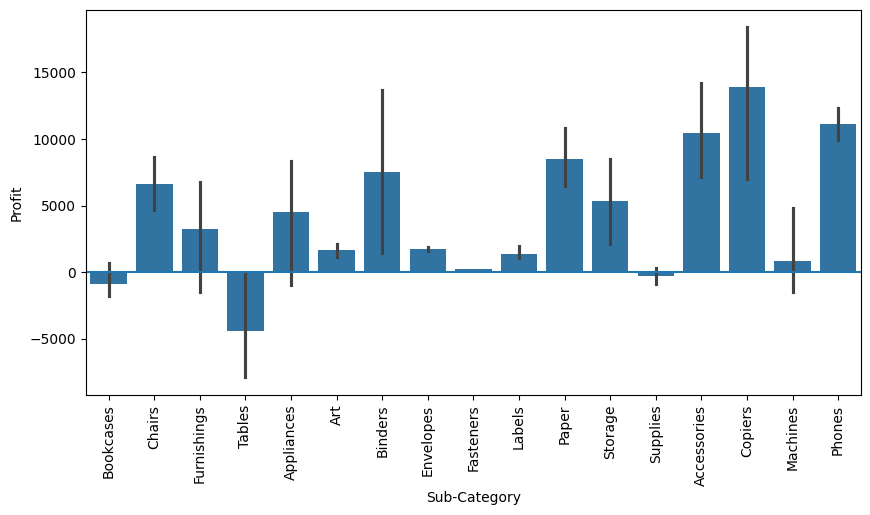

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=grouped, x='Sub-Category', y='Profit')
plt.xticks(rotation=90)
plt.axhline(0)
plt.show()

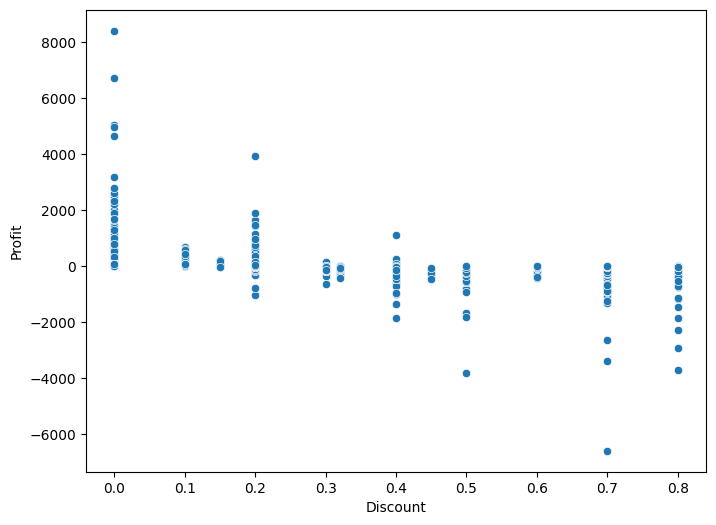

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.show() #elaqeni gosterir

In [14]:
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

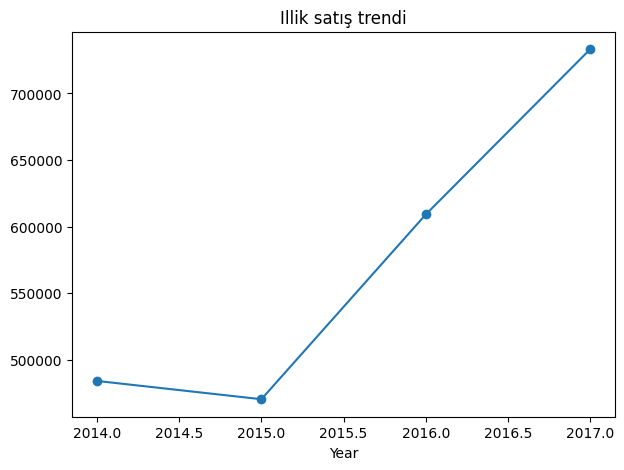

In [21]:
plt.figure(figsize=(7,5))
yearly_sales.plot(marker='o')
plt.title("Illik satış trendi")
plt.show()

In [23]:
category_margin = df.groupby('Category')[['Sales','Profit']].sum()
category_margin['Profit_Margin_%'] = (category_margin['Profit'] / category_margin['Sales']) * 100
category_margin #bonusda profit margin

,Sales,Profit,Profit_Margin_%
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


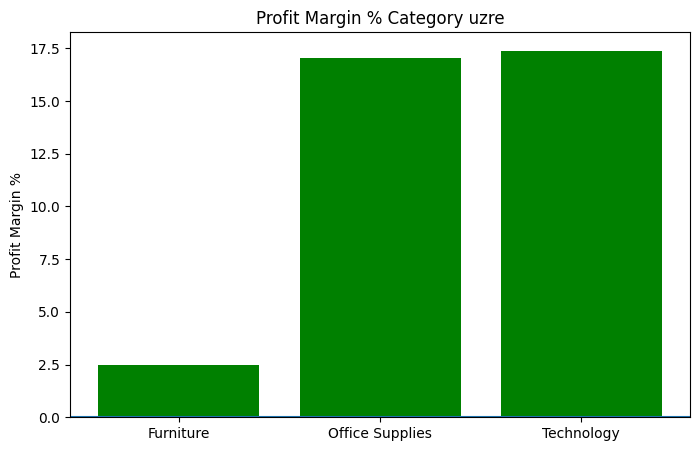

In [25]:
colors = ['green' if x > 0 else 'red' for x in category_margin['Profit_Margin_%']]
plt.figure(figsize=(8,5))
plt.bar(category_margin.index, category_margin['Profit_Margin_%'], color=colors)
plt.axhline(0)
plt.title("Profit Margin % Category uzre")
plt.ylabel("Profit Margin %")
plt.show()

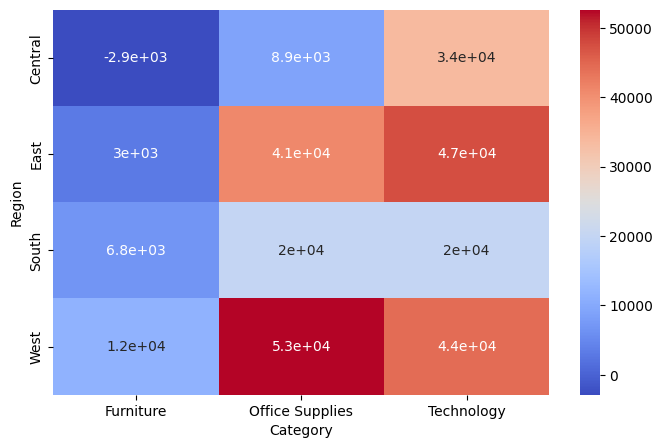

In [27]:
pivot = df.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='sum')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.show()